In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import scarf

scarf.set_verbosity('WARNING')
scarf.__version__

'1.0.0'

In [2]:
dataset_root = Path('./scarf_datasets')
dataset_path = (
    dataset_root
    / 'bastidas-ponce_4K_pancreas-d15_rnaseq'
    / 'data.zarr'
)
if not dataset_path.exists():
    scarf.cytebase.connect("scarf_docs").download_dataset(
        name='bastidas-ponce_4K_pancreas-d15_rnaseq',
        destination=str(dataset_root),
        zarr=True,
    )

In [3]:
ds = scarf.DataStore(
    str(dataset_path),
    nthreads=4,
    default_assay='RNA',
)

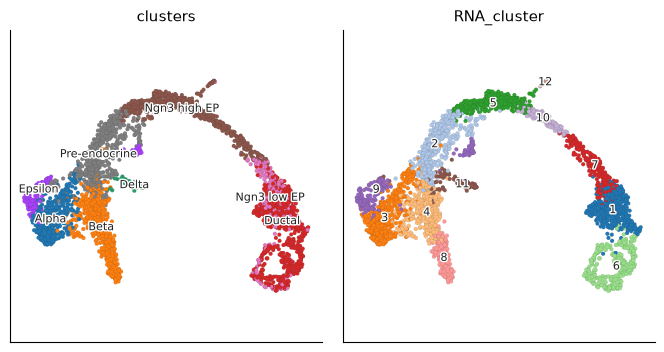

PlotResult(axes=2, tables=0, legends=2, scales=3, owns_figure=True, rendered=True)

In [4]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['clusters', 'RNA_cluster'],
    legend_loc='on_data',
)

In [5]:
annotations = ds.cells.to_pandas_dataframe(
    columns=['RNA_cluster', 'clusters'],
    key='I',
)
terminal_cell_types = ['Alpha', 'Beta', 'Delta']
terminal_clusters = {
    cell_type: annotations.loc[
        annotations['clusters'] == cell_type,
        'RNA_cluster',
    ].value_counts().idxmax()
    for cell_type in terminal_cell_types
}
terminal_clusters

{'Alpha': np.int32(3), 'Beta': np.int32(4), 'Delta': np.int32(11)}

In [6]:
source_clusters = [1]
sink_clusters = list(terminal_clusters.values())

assert len(set(sink_clusters)) == len(terminal_cell_types)
assert set(source_clusters).isdisjoint(sink_clusters)

In [7]:
pseudotime = ds.run_pseudotime_scoring(
    source_sink_key='RNA_cluster',
    sources=source_clusters,
    sinks=sink_clusters,
    label='fate_pseudotime',
)

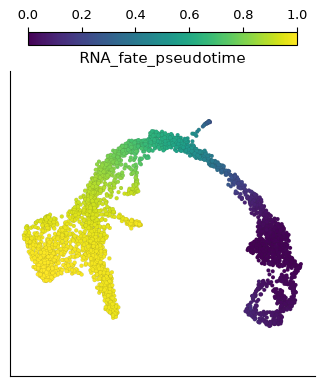

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [8]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=pseudotime.pseudotime_key,
    subset_by=pseudotime.validity_key,
)

In [9]:
fate = ds.run_fate_mapping(
    cell_key='I',
    subset_cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
    sink_key='clusters',
    sinks=terminal_cell_types,
)

In [10]:
pd.Series(
    dict(zip(fate.sink_labels, fate.fate_keys, strict=True)),
    name='cell metadata key',
)

Alpha    RNA_RNA_fate_pseudotime__valid_fate_Alpha
Beta      RNA_RNA_fate_pseudotime__valid_fate_Beta
Delta    RNA_RNA_fate_pseudotime__valid_fate_Delta
Name: cell metadata key, dtype: object

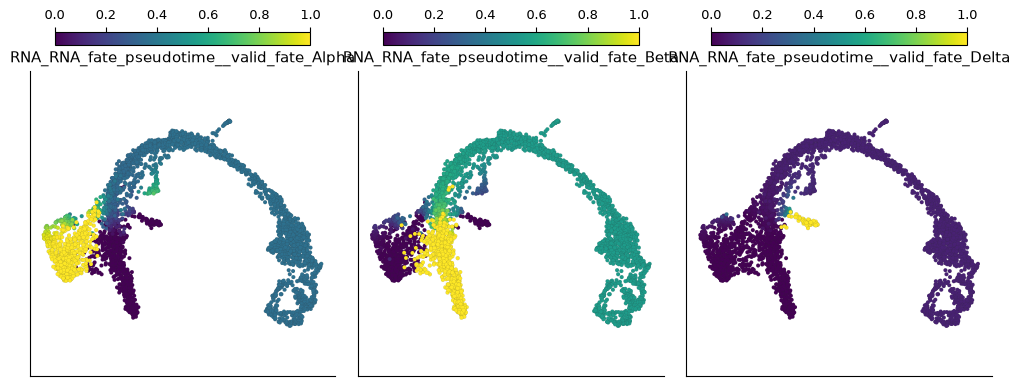

PlotResult(axes=3, tables=0, legends=3, scales=1, owns_figure=True, rendered=True)

In [11]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=list(fate.fate_keys),
    subset_by=fate.validity_key,
    n_columns=3,
    sort_values=True,
)

In [12]:
valid_probabilities = fate.values[fate.valid]
simplex_error = float(
    np.max(np.abs(valid_probabilities.sum(axis=1) - 1.0))
)
assert simplex_error < 1e-5
simplex_error

1.1920928955078125e-07

In [13]:
selected_labels = ds.cells.fetch(
    fate.sink_key,
    key=fate.result_cell_key,
)
terminal_checks = []
for index, sink in enumerate(fate.sink_labels):
    rows = (selected_labels == sink) & fate.valid
    own_probability = fate.values[rows, index]
    other_probability = np.delete(fate.values[rows], index, axis=1)
    np.testing.assert_array_equal(
        own_probability,
        np.ones(own_probability.shape[0], dtype=np.float32),
    )
    assert np.count_nonzero(other_probability) == 0
    terminal_checks.append(
        {
            'sink': sink,
            'cells': int(rows.sum()),
            'minimum own probability': float(own_probability.min()),
            'maximum other probability': float(other_probability.max()),
        }
    )

pd.DataFrame(terminal_checks)

,sink,cells,minimum own probability,maximum other probability
0,Alpha,454,1.0,0.0
1,Beta,573,1.0,0.0
2,Delta,70,1.0,0.0
